# Статистический анализ данных Home Credit

Цель работы - сформулировать и проверить несколько статистических гипотез на основе признаков,
полученных из доменов application, bureau и bureau_balance.

Для всех статистических тестов фиксируется вероятность ошибки 1 рода
на уровне alpha = 0.05

In [1]:
import sys
from pathlib import Path

# путь до папки notebooks
notebook_path = Path().resolve()

# поднимаемся на уровень проекта
project_root = notebook_path.parent

# путь до src
src_path = project_root / "src"

if str(src_path) not in sys.path:
    sys.path.append(str(src_path))

print("PROJECT ROOT:", project_root)
print("SRC PATH:", src_path)

PROJECT ROOT: C:\Users\denis\credit_scoring
SRC PATH: C:\Users\denis\credit_scoring\src


In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from scipy import stats
from scipy.stats import mannwhitneyu, ttest_ind, chi2_contingency

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from config.db_config import DB_ARGS
from app.utils.db_manager import PostgresDB

In [3]:
db = PostgresDB(DB_ARGS)
db.connect()

Подключение к БД успешно установлено


In [4]:
query = """
SELECT
    a.SK_ID_CURR,
    a.TARGET,
    a.AMT_ANNUITY,
    a.AMT_INCOME_TOTAL,
    a.EXT_SOURCE_1,
    a.EXT_SOURCE_2,
    a.EXT_SOURCE_3
FROM application a
WHERE a.TARGET IS NOT NULL
"""

df = db.get_df(query)
df.columns = df.columns.str.upper()

print(df.columns.tolist())
df.head()

C:\Users\denis\credit_scoring\src\app\utils\db_manager.py:134: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(query, self.conn, params=params)


Время выполнения: 0:00:02
['SK_ID_CURR', 'TARGET', 'AMT_ANNUITY', 'AMT_INCOME_TOTAL', 'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']


,SK_ID_CURR,TARGET,AMT_ANNUITY,AMT_INCOME_TOTAL,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3
0,124721,0,27193.5,315000.0,0.579902,0.589356,0.294083
1,148467,0,22743.0,247500.0,0.430604,0.674981,0.651260
2,124762,0,26797.5,157500.0,0.613530,0.737998,0.722393
3,166746,0,14350.5,31500.0,NaN,0.302726,0.740799
4,166769,0,48127.5,135000.0,NaN,0.681613,NaN


In [5]:
df["payment_income_share"] = (
    df["AMT_ANNUITY"] / df["AMT_INCOME_TOTAL"]
)

df["weighted_ext_score"] = (
    0.2 * df["EXT_SOURCE_1"].fillna(0) +
    0.5 * df["EXT_SOURCE_2"].fillna(0) +
    0.3 * df["EXT_SOURCE_3"].fillna(0)
)

df[["TARGET", "payment_income_share", "weighted_ext_score"]].head()

,TARGET,payment_income_share,weighted_ext_score
0,0,0.086329,0.498883
1,0,0.091891,0.618989
2,0,0.170143,0.708423
3,0,0.455571,0.373603
4,0,0.356500,0.340807


In [6]:
good_clients = df.loc[df["TARGET"] == 0, "payment_income_share"].dropna()
bad_clients = df.loc[df["TARGET"] == 1, "payment_income_share"].dropna()

print("TARGET=0:", good_clients.shape)
print("TARGET=1:", bad_clients.shape)

TARGET=0: (282674,)
TARGET=1: (24825,)


In [7]:
stats_summary = pd.DataFrame({
    "good_mean": [good_clients.mean()],
    "bad_mean": [bad_clients.mean()],
    "good_median": [good_clients.median()],
    "bad_median": [bad_clients.median()],
    "good_std": [good_clients.std()],
    "bad_std": [bad_clients.std()],
})

stats_summary

,good_mean,bad_mean,good_median,bad_median,good_std,bad_std
0,0.18053,0.185482,0.16228,0.169294,0.09457,0.094497


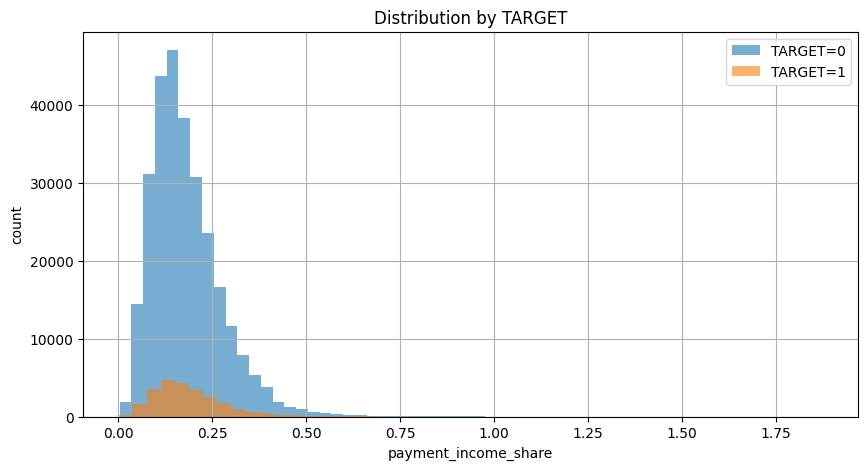

In [8]:
plt.figure(figsize=(10, 5))

plt.hist(good_clients, bins=50, alpha=0.6, label="TARGET=0")
plt.hist(bad_clients, bins=50, alpha=0.6, label="TARGET=1")

plt.xlabel("payment_income_share")
plt.ylabel("count")
plt.title("Distribution by TARGET")
plt.legend()
plt.grid()
plt.show()

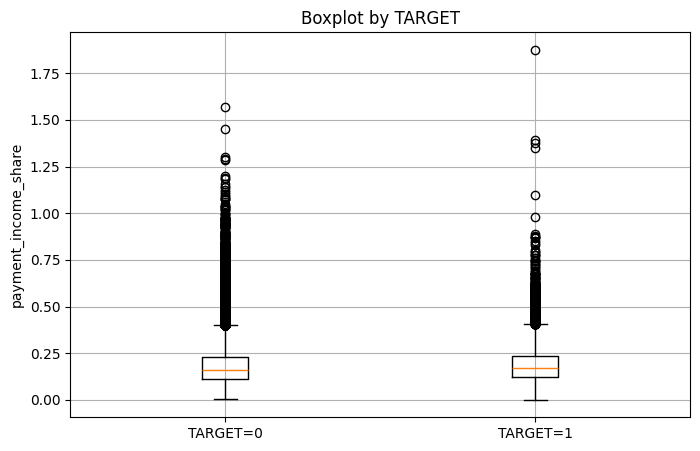

In [9]:
plt.figure(figsize=(8, 5))

plt.boxplot([good_clients, bad_clients], tick_labels=["TARGET=0", "TARGET=1"])

plt.ylabel("payment_income_share")
plt.title("Boxplot by TARGET")
plt.grid()
plt.show()

### Гипотеза 1. Кредитная нагрузка и дефолт

Проверяется гипотеза о том, что доля дохода, направляемая на выплату займа
(`payment_income_share`), различается между дефолтными и недефолтными клиентами.

**H0:** распределения признака одинаковы в группах TARGET=0 и TARGET=1

**H1:** распределения различаются

Так как распределение признака асимметрично и содержит большое количество выбросов,
используется непараметрический критерий Манна–Уитни.

In [10]:
from scipy.stats import mannwhitneyu

stat, p_value = mannwhitneyu(
    good_clients,
    bad_clients,
    alternative="two-sided"
)

print("U-statistic:", stat)
print("p-value:", p_value)

U-statistic: 3371632252.5
p-value: 1.599035370488435e-24


### Результат проверки гипотезы 1

По результатам критерия Манна–Уитни получено:

- U-statistic = 3371632252.5
- p-value = 1.6e-24


Так как p-value < 0.05, нулевая гипотеза отвергается.

Следовательно, распределения признака `payment_income_share`
в группах TARGET=0 и TARGET=1 статистически значимо различаются.

По boxplot видно, что медиана признака у дефолтных клиентов выше.

Это подтверждает гипотезу:
чем большую долю дохода клиент тратит на обслуживание займа,
тем выше вероятность дефолта.

In [11]:
good_score = df.loc[df["TARGET"] == 0, "weighted_ext_score"].dropna()
bad_score = df.loc[df["TARGET"] == 1, "weighted_ext_score"].dropna()

print("TARGET=0:", good_score.shape)
print("TARGET=1:", bad_score.shape)

TARGET=0: (282686,)
TARGET=1: (24825,)


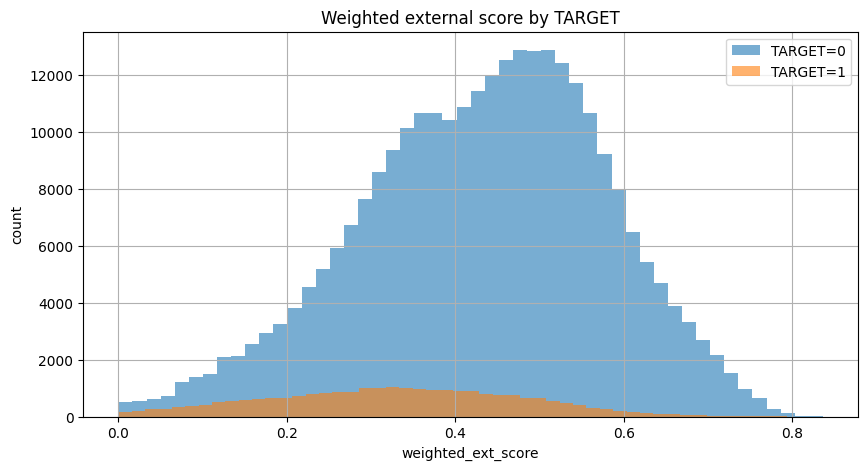

In [12]:
plt.figure(figsize=(10, 5))

plt.hist(good_score, bins=50, alpha=0.6, label="TARGET=0")
plt.hist(bad_score, bins=50, alpha=0.6, label="TARGET=1")

plt.xlabel("weighted_ext_score")
plt.ylabel("count")
plt.title("Weighted external score by TARGET")
plt.legend()
plt.grid()
plt.show()

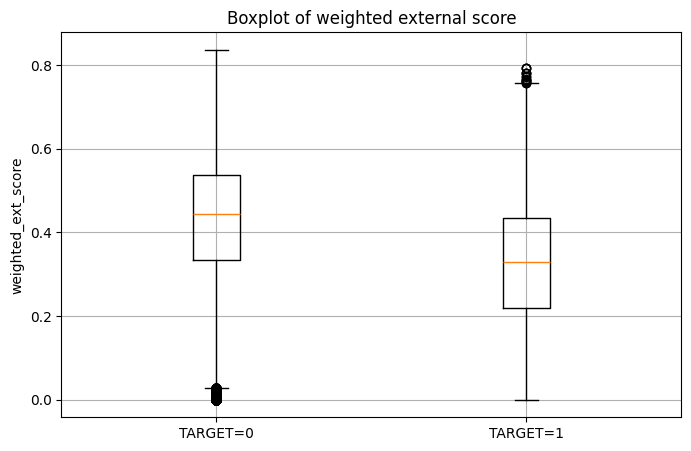

In [13]:
plt.figure(figsize=(8, 5))

plt.boxplot(
    [good_score, bad_score],
    tick_labels=["TARGET=0", "TARGET=1"]
)

plt.ylabel("weighted_ext_score")
plt.title("Boxplot of weighted external score")
plt.grid()
plt.show()

In [14]:
from scipy.stats import normaltest


for label, sample in {
    "TARGET=0": good_score,
    "TARGET=1": bad_score,
}.items():
    stat, p_value = normaltest(sample)

    print(f"{label}")
    print(f"statistic = {stat:.4f}")
    print(f"p-value = {p_value:.4e}")

    if p_value < 0.05:
        print("распределение отличается от нормального.\n")
    else:
        print("нет оснований отвергать нормальность.\n")

TARGET=0
statistic = 4846.2010
p-value = 0.0000e+00
распределение отличается от нормального.

TARGET=1
statistic = 606.3285
p-value = 2.1749e-132
распределение отличается от нормального.



### Гипотеза 2. Внешний скор и дефолт

Проверяется гипотеза о том, что у дефолтных клиентов
взвешенный внешний скор ниже.

**H0:** распределение `weighted_ext_score`
у дефолтных клиентов не ниже

**H1:** у дефолтных клиентов внешний скор ниже

Используется критерий Манна–Уитни,
так как распределение признака не является нормальным.

In [14]:
from scipy.stats import mannwhitneyu

stat, p_value = mannwhitneyu(
    bad_score,
    good_score,
    alternative="less"
)

print("U-statistic:", stat)
print("p-value:", p_value)

U-statistic: 2147414332.0
p-value: 0.0


### Результат проверки гипотезы 2

По результатам критерия Манна–Уитни получено:

- U-statistic = 2147414332.0
- p-value = 0

Так как p-value < 0.05, нулевая гипотеза отвергается.

Следовательно, взвешенный внешний скор
у дефолтных клиентов статистически значимо ниже,
чем у недефолтных.

Это полностью соответствует гипотезе:
внешние скоринговые источники хорошо разделяют
рискованные и надежные заявки.

In [15]:
query_gender = """
SELECT
    SK_ID_CURR,
    TARGET,
    CODE_GENDER
FROM application
WHERE TARGET IS NOT NULL
"""

df_gender = db.get_df(query_gender)
df_gender.columns = df_gender.columns.str.upper()

df_gender.head()

C:\Users\denis\credit_scoring\src\app\utils\db_manager.py:134: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(query, self.conn, params=params)


Время выполнения: 0:00:03


,SK_ID_CURR,TARGET,CODE_GENDER
0,124721,0,F
1,148467,0,F
2,124762,0,F
3,166746,0,F
4,166769,0,F


In [16]:
contingency_table = pd.crosstab(
    df_gender["CODE_GENDER"],
    df_gender["TARGET"]
)

contingency_table

TARGET,0,1
CODE_GENDER,,
F,188278,14170
M,94404,10655
XNA,4,0


In [17]:
from scipy.stats import chi2_contingency

chi2, p_value, dof, expected = chi2_contingency(contingency_table)

print("chi2:", chi2)
print("p-value:", p_value)
print("degrees of freedom:", dof)

chi2: 920.7913340361749
p-value: 1.1290217848908289e-200
degrees of freedom: 2


### Гипотеза 3. Зависимость дефолта от пола

Проверяется гипотеза о наличии зависимости между полом клиента
и фактом дефолта.

**H0:** TARGET не зависит от пола клиента

**H1:** TARGET зависит от пола клиента

Для проверки используется критерий χ² Пирсона,
так как обе переменные категориальные.

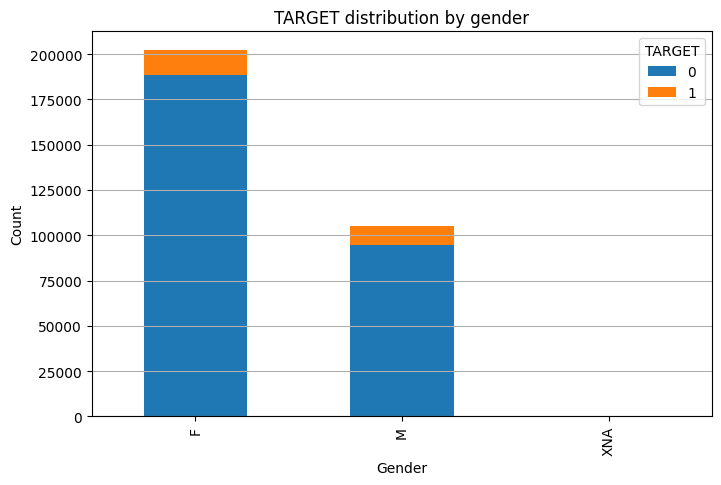

In [18]:
gender_target_counts = pd.crosstab(
    df_gender["CODE_GENDER"],
    df_gender["TARGET"]
)

gender_target_counts.plot(
    kind="bar",
    stacked=True,
    figsize=(8, 5)
)

plt.title("TARGET distribution by gender")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.grid(axis="y")
plt.show()

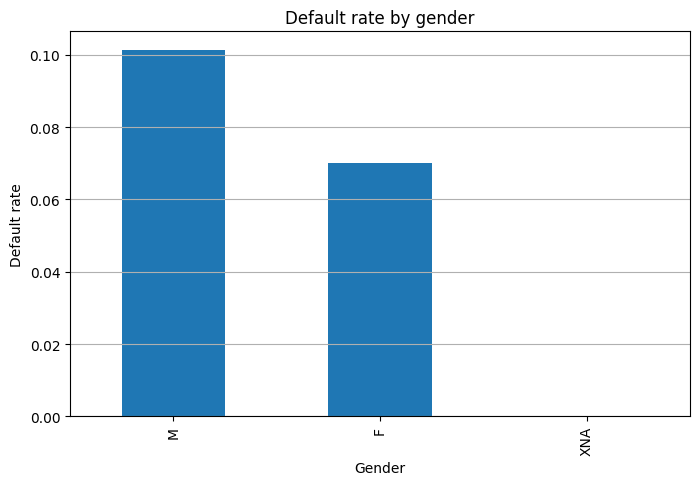

In [19]:
default_rate_by_gender = (
    df_gender.groupby("CODE_GENDER")["TARGET"]
    .mean()
    .sort_values(ascending=False)
)

default_rate_by_gender.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Default rate by gender")
plt.xlabel("Gender")
plt.ylabel("Default rate")
plt.grid(axis="y")
plt.show()

### Результат проверки гипотезы 3

По результатам критерия χ² Пирсона получено:

- χ² = 920.79
- p-value = 1.13e-200

Так как p-value < 0.05, нулевая гипотеза отвергается.

Между полом клиента и фактом дефолта
наблюдается статистически значимая зависимость.

По графику доли дефолтов видно, что среди мужчин
доля дефолтов составляет около 10.1%,
тогда как среди женщин около 7.0%.

Получается, что  мужчины в данном датасете
демонстрируют более высокий риск дефолта.

### Гипотеза 4. Связь между внешним скором и кредитной нагрузкой

Проверяется гипотеза о наличии отрицательной связи
между внешним скором клиента и его кредитной нагрузкой.

**H0:** между признаками нет зависимости

**H1:** существует отрицательная зависимость

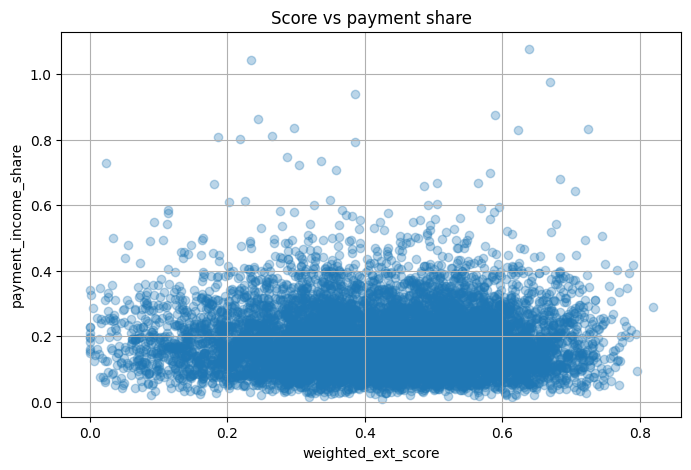

In [20]:
sample_df = df.sample(10000, random_state=42)

plt.figure(figsize=(8, 5))

plt.scatter(
    sample_df["weighted_ext_score"],
    sample_df["payment_income_share"],
    alpha=0.3
)

plt.xlabel("weighted_ext_score")
plt.ylabel("payment_income_share")
plt.title("Score vs payment share")
plt.grid()
plt.show()

In [21]:
from scipy.stats import spearmanr

corr, p_value = spearmanr(
    df["weighted_ext_score"],
    df["payment_income_share"],
    nan_policy="omit"
)

print("Spearman correlation:", corr)
print("p-value:", p_value)

Spearman correlation: -0.017579313358734017
p-value: 1.8648041693502757e-22


### Результат проверки гипотезы 4

По результатам коэффициента ранговой корреляции Спирмена получено:

- ρ = -0.0176
- p-value = 1.86e-22

Так как p-value < 0.05, нулевая гипотеза отвергается.

Однако значение коэффициента корреляции
очень близко к нулю.

Это может означать, что статистически зависимость существует,
но её сила крайне мала.

Практической значимости
для данной зависимости почти нет.

Есть предположение,что столь малое p-value объясняется
очень большим размером выборки.

In [22]:
query_pca = """
SELECT
    TARGET,
    AMT_CREDIT,
    AMT_INCOME_TOTAL,
    DAYS_BIRTH,
    AMT_ANNUITY,
    EXT_SOURCE_1,
    EXT_SOURCE_2,
    EXT_SOURCE_3
FROM application
WHERE TARGET IS NOT NULL
"""

pca_df = db.get_df(query_pca)
pca_df.columns = pca_df.columns.str.upper()

pca_df.head()

C:\Users\denis\credit_scoring\src\app\utils\db_manager.py:134: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(query, self.conn, params=params)


Время выполнения: 0:00:04


,TARGET,AMT_CREDIT,AMT_INCOME_TOTAL,DAYS_BIRTH,AMT_ANNUITY,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3
0,0,450000.0,315000.0,-12293,27193.5,0.579902,0.589356,0.294083
1,0,445500.0,247500.0,-14881,22743.0,0.430604,0.674981,0.651260
2,0,916470.0,157500.0,-20993,26797.5,0.613530,0.737998,0.722393
3,0,254700.0,31500.0,-21503,14350.5,NaN,0.302726,0.740799
4,0,1506816.0,135000.0,-18358,48127.5,NaN,0.681613,NaN


In [23]:
pca_df["payment_income_share"] = (
    pca_df["AMT_ANNUITY"] / pca_df["AMT_INCOME_TOTAL"]
)

pca_df["weighted_ext_score"] = (
    0.2 * pca_df["EXT_SOURCE_1"].fillna(0) +
    0.5 * pca_df["EXT_SOURCE_2"].fillna(0) +
    0.3 * pca_df["EXT_SOURCE_3"].fillna(0)
)

features = pca_df[
    [
        "AMT_CREDIT",
        "AMT_INCOME_TOTAL",
        "DAYS_BIRTH",
        "payment_income_share",
        "weighted_ext_score"
    ]
].copy()

target = pca_df["TARGET"]

In [24]:
from sklearn.preprocessing import StandardScaler

features = features.fillna(features.median())

scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)

In [25]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

print("Explained variance ratio:", pca.explained_variance_ratio_)

Explained variance ratio: [0.28672319 0.23094919]


C:\Users\denis\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


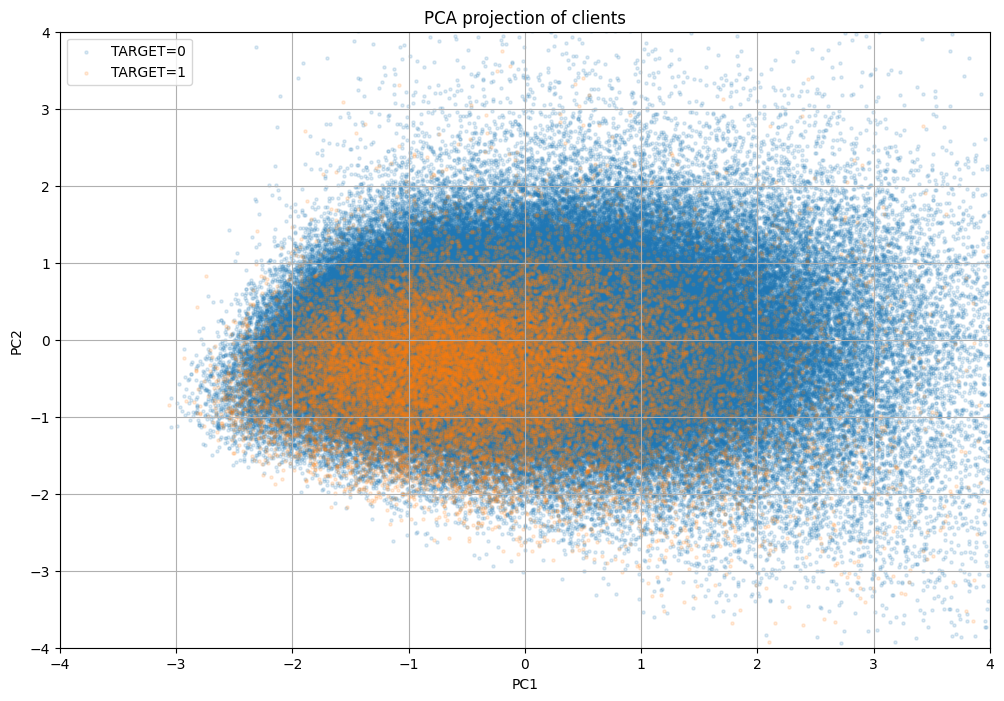

In [26]:
plt.figure(figsize=(12, 8))

plt.scatter(
    X_pca[target == 0, 0],
    X_pca[target == 0, 1],
    alpha=0.15,
    s=5,
    label="TARGET=0"
)

plt.scatter(
    X_pca[target == 1, 0],
    X_pca[target == 1, 1],
    alpha=0.15,
    s=5,
    label="TARGET=1"
)

plt.xlim(-4, 4)
plt.ylim(-4, 4)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA projection of clients")
plt.legend()
plt.grid()
plt.show()

In [27]:
explained = pca.explained_variance_ratio_

print(f"PC1 explains {explained[0]:.2%}")
print(f"PC2 explains {explained[1]:.2%}")
print(f"Total explained variance {explained.sum():.2%}")

PC1 explains 28.67%
PC2 explains 23.09%
Total explained variance 51.77%


### Интерпретация PCA

Метод главных компонент был применен
для снижения размерности признакового пространства до 2 измерений.

Первая главная компонента объясняет 28.67% дисперсии,
вторая - 23.09%.

Суммарно две компоненты объясняют 51.77% общей дисперсии данных.

По графику видно, что классы TARGET=0 и TARGET=1
существенно перекрываются.

Это говорит о том, что в пространстве первых двух компонент
дефолтные и недефолтные клиенты
не образуют четко разделимых кластеров.

Заметим, дефолтные клиенты
демонстрируют несколько более высокую плотность
в центральной области распределения.

In [28]:
group_0 = df.loc[df["TARGET"] == 0, "weighted_ext_score"].dropna().values
group_1 = df.loc[df["TARGET"] == 1, "weighted_ext_score"].dropna().values

n_boot = 2000
boot_diffs = []

for _ in range(n_boot):
    sample_0 = np.random.choice(group_0, size=len(group_0), replace=True)
    sample_1 = np.random.choice(group_1, size=len(group_1), replace=True)

    diff = np.median(sample_0) - np.median(sample_1)
    boot_diffs.append(diff)

boot_diffs = np.array(boot_diffs)

ci_low = np.percentile(boot_diffs, 2.5)
ci_high = np.percentile(boot_diffs, 97.5)

print(f"Median difference: {boot_diffs.mean():.4f}")
print(f"95% CI: [{ci_low:.4f}, {ci_high:.4f}]")

Median difference: 0.1151
95% CI: [0.1124, 0.1175]


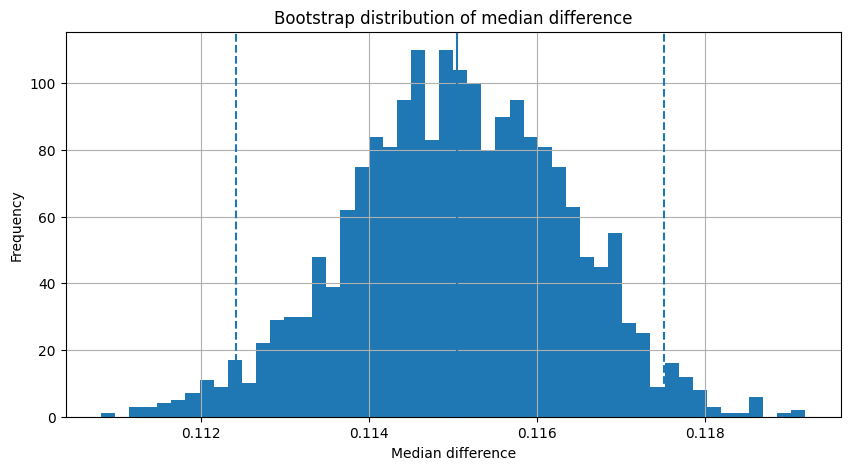

In [29]:
plt.figure(figsize=(10, 5))
plt.hist(boot_diffs, bins=50)
plt.axvline(ci_low, linestyle="--")
plt.axvline(ci_high, linestyle="--")
plt.axvline(boot_diffs.mean(), linestyle="-")
plt.title("Bootstrap distribution of median difference")
plt.xlabel("Median difference")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()

### Bootstrap validation

Для проверки устойчивости различий между группами
дополнительно применён bootstrap для разницы медиан
признака `weighted_ext_score`.

Средняя bootstrap-оценка разницы медиан составила **0.1151**.

95% доверительный интервал:

**[0.1124 ; 0.1175]**

Поскольку интервал не содержит 0,
различие между группами является статистически устойчивым.

Это подтверждает результаты критерия Манна-Уитни
и дополнительно снижает вероятность ошибки 2 рода.

## Итоговый вывод

В ходе исследования были сформулированы
и проверены несколько статистических гипотез
с использованием различных критериев:

- критерий Манна–Уитни
- χ² Пирсона
- корреляция Спирмена
- PCA

Результаты показали, что:

- кредитная нагрузка значимо выше у дефолтных клиентов
- внешний скор значимо ниже у дефолтных клиентов
- наблюдается статистическая зависимость между полом и дефолтом
- между некоторыми признаками статистическая зависимость может быть значимой,
  но практически слабой
- в пространстве главных компонент классы существенно перекрываются
